In [1]:
# ============================================================
# CLEAN EVALUATION NOTEBOOK
# Qwen2.5-3B Base vs Fine-Tuned Qwen2.5-3B + LoRA
#
# IMPORTANT:
# - This is a NEW Kaggle notebook.
# - DO NOT import unsloth anywhere.
# - No API key required.
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL ONLY WHAT IS NEEDED
# ------------------------------------------------------------
!pip -q install rouge-score sentence-transformers peft accelerate bitsandbytes datasets


# ------------------------------------------------------------
# 2. IMPORTS
# ------------------------------------------------------------
import os
import gc
import json
import random
import sys
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

from peft import PeftModel
from datasets import load_dataset

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

from sentence_transformers import SentenceTransformer


# ------------------------------------------------------------
# 3. ENVIRONMENT CHECK
# ------------------------------------------------------------
print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)

try:
    import transformers
    print("Transformers:", transformers.__version__)
except Exception as e:
    print("Transformers version check failed:", e)

try:
    import peft
    print("PEFT:", peft.__version__)
except Exception as e:
    print("PEFT version check failed:", e)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ------------------------------------------------------------
# 4. MAKE SURE UNSLOTH HAS NOT BEEN IMPORTED
# ------------------------------------------------------------
unsloth_loaded = any(
    name == "unsloth" or name.startswith("unsloth.")
    for name in sys.modules
)

print("Unsloth imported:", unsloth_loaded)

if unsloth_loaded:
    raise RuntimeError(
        "\nUnsloth is already imported in this notebook.\n"
        "DO NOT continue.\n"
        "Create/restart a fresh Kaggle session and run "
        "this evaluation notebook without importing Unsloth."
    )

print("\nEnvironment looks clean.")


# ------------------------------------------------------------
# 5. FIND THE LORA ADAPTER AUTOMATICALLY
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SEARCHING FOR LORA ADAPTER")
print("=" * 70)

adapter_config_paths = []

for root, dirs, files in os.walk("/kaggle/input"):
    if "adapter_config.json" in files:
        adapter_config_paths.append(
            os.path.join(root, "adapter_config.json")
        )

if not adapter_config_paths:
    raise FileNotFoundError(
        "\nCould not find adapter_config.json under /kaggle/input.\n"
        "Make sure the qwen_model input is attached."
    )

print("Found adapter config:")

for p in adapter_config_paths:
    print(" ", p)

# Use the first adapter found
adapter_config_path = adapter_config_paths[0]
LORA_ADAPTER = os.path.dirname(adapter_config_path)

print("\nUsing LoRA adapter:")
print(LORA_ADAPTER)

# Verify weights
weight_candidates = [
    "adapter_model.safetensors",
    "adapter_model.bin",
]

if not any(
    os.path.exists(
        os.path.join(LORA_ADAPTER, x)
    )
    for x in weight_candidates
):
    raise FileNotFoundError(
        "\nFound adapter_config.json but no adapter weights."
    )

print("\nAdapter files:")

for f in sorted(os.listdir(LORA_ADAPTER)):
    print(" ", f)


# ------------------------------------------------------------
# 6. CONFIG
# ------------------------------------------------------------
BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"

DATASET_NAME = "ed001/ds-coder-instruct-v1"

SEED = 3407

TEST_SIZE = 0.02

N_EVAL = 100

MAX_INPUT_TOKENS = 2048

MAX_NEW_TOKENS = 512

OUTPUT_DIR = "/kaggle/working/evaluation_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# 7. LOAD DATASET
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("LOADING DATASET")
print("=" * 70)

dataset = load_dataset(
    DATASET_NAME
)

print(dataset)

if "train" in dataset:
    full_dataset = dataset["train"]
else:
    full_dataset = dataset[
        list(dataset.keys())[0]
    ]

print(
    "\nTotal rows:",
    len(full_dataset)
)

print(
    "Columns:",
    full_dataset.column_names
)


# ------------------------------------------------------------
# 8. RECREATE VALIDATION SPLIT
# ------------------------------------------------------------
split_dataset = full_dataset.train_test_split(
    test_size=TEST_SIZE,
    seed=SEED
)

eval_dataset = split_dataset["test"]

print(
    "Validation rows:",
    len(eval_dataset)
)

N_EVAL = min(
    N_EVAL,
    len(eval_dataset)
)

eval_dataset = eval_dataset.select(
    range(N_EVAL)
)

print(
    "Rows to evaluate:",
    len(eval_dataset)
)


# ------------------------------------------------------------
# 9. BUILD QUESTION / ANSWER PAIRS
# ------------------------------------------------------------
def build_question(example):

    instruction = example.get(
        "instruction",
        ""
    )

    input_text = example.get(
        "input",
        ""
    )

    instruction = (
        "" if instruction is None
        else str(instruction)
    )

    input_text = (
        "" if input_text is None
        else str(input_text)
    )

    if input_text.strip():
        return (
            instruction.strip()
            + "\n\n"
            + input_text.strip()
        )

    return instruction.strip()


examples = []

for item in eval_dataset:

    question = build_question(item)

    reference = item.get(
        "output",
        ""
    )

    reference = (
        "" if reference is None
        else str(reference)
    )

    if question.strip() and reference.strip():

        examples.append({
            "question": question.strip(),
            "reference": reference.strip()
        })


print(
    "\nValid evaluation pairs:",
    len(examples)
)

if not examples:
    raise RuntimeError(
        "No valid question/answer pairs found."
    )


# ------------------------------------------------------------
# 10. LOAD TOKENIZER
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("LOADING TOKENIZER")
print("=" * 70)

# Prefer tokenizer from the adapter folder because it was
# saved alongside the fine-tuned model.
try:

    tokenizer = AutoTokenizer.from_pretrained(
        LORA_ADAPTER,
        use_fast=True
    )

    print(
        "Loaded tokenizer from LoRA folder."
    )

except Exception:

    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL,
        use_fast=True
    )

    print(
        "Loaded tokenizer from base model."
    )


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"


# ------------------------------------------------------------
# 11. 4-BIT CONFIG
# ------------------------------------------------------------
bnb_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_use_double_quant=True,

    bnb_4bit_compute_dtype=torch.float16,
)


# ------------------------------------------------------------
# 12. MODEL LOADER
# ------------------------------------------------------------
def load_base_model():

    print(
        "\nLoading:",
        BASE_MODEL
    )

    model = AutoModelForCausalLM.from_pretrained(

        BASE_MODEL,

        quantization_config=bnb_config,

        torch_dtype=torch.float16,

        device_map="auto",

        low_cpu_mem_usage=True,
    )

    model.eval()

    model.config.use_cache = True

    return model


# ------------------------------------------------------------
# 13. VERIFY ATTENTION IMPLEMENTATION
# ------------------------------------------------------------
def verify_attention(model):

    print(
        "\nChecking Qwen2 attention implementation..."
    )

    found = False

    for module in model.modules():

        module_name = type(module).__name__

        if module_name == "Qwen2Attention":

            found = True

            forward_module = (
                module.forward.__module__
            )

            print(
                "Attention class:",
                module_name
            )

            print(
                "Forward implementation:",
                forward_module
            )

            if "unsloth" in forward_module.lower():

                raise RuntimeError(
                    "\nUNSLOTH ATTENTION DETECTED!\n"
                    f"Forward module: {forward_module}\n"
                    "This notebook must be restarted."
                )

            print(
                "✓ Clean Transformers attention detected."
            )

            break

    if not found:

        print(
            "Warning: Qwen2Attention class was not found "
            "during inspection."
        )


# ------------------------------------------------------------
# 14. GENERATION FUNCTION
# ------------------------------------------------------------
@torch.inference_mode()
def generate_answer(
    model,
    question
):

    messages = [

        {
            "role": "system",
            "content": (
                "You are a helpful Data Science assistant. "
                "Give accurate, practical answers. "
                "Use Python code when appropriate."
            )
        },

        {
            "role": "user",
            "content": question
        }

    ]

    prompt = tokenizer.apply_chat_template(

        messages,

        tokenize=False,

        add_generation_prompt=True
    )

    inputs = tokenizer(

        prompt,

        return_tensors="pt",

        truncation=True,

        max_length=MAX_INPUT_TOKENS
    )

    # Move to model device
    device = next(
        model.parameters()
    ).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    output_ids = model.generate(

        **inputs,

        max_new_tokens=MAX_NEW_TOKENS,

        do_sample=False,

        num_beams=1,

        use_cache=True,

        pad_token_id=tokenizer.pad_token_id,

        eos_token_id=tokenizer.eos_token_id,
    )

    input_length = (
        inputs["input_ids"].shape[1]
    )

    generated_ids = (
        output_ids[0][input_length:]
    )

    answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return answer.strip()


# ------------------------------------------------------------
# 15. SANITY TEST
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SANITY TEST")
print("=" * 70)

test_model = load_base_model()

verify_attention(test_model)

test_question = (
    "What is the difference between "
    "classification and regression in "
    "machine learning?"
)

print("\nGenerating test answer...")

test_answer = generate_answer(
    test_model,
    test_question
)

print("\nQUESTION:")
print(test_question)

print("\nANSWER:")
print(test_answer)

if not test_answer:

    raise RuntimeError(
        "\nGeneration returned an empty answer."
    )

print(
    "\n✓ SANITY TEST PASSED."
)

del test_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 16. METRIC SETUP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("LOADING METRIC MODEL")
print("=" * 70)

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

smooth = SmoothingFunction().method1

semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)


def rouge_l_score(
    reference,
    prediction
):

    return rouge.score(
        reference,
        prediction
    )["rougeL"].fmeasure


def bleu_score(
    reference,
    prediction
):

    ref_tokens = reference.split()

    pred_tokens = prediction.split()

    if not pred_tokens:
        return 0.0

    return sentence_bleu(

        [ref_tokens],

        pred_tokens,

        smoothing_function=smooth
    )


def semantic_similarity(
    reference,
    prediction
):

    embeddings = semantic_model.encode(

        [
            reference,
            prediction
        ],

        convert_to_tensor=True,

        normalize_embeddings=True,

        show_progress_bar=False
    )

    return float(
        torch.sum(
            embeddings[0] * embeddings[1]
        ).item()
    )


# ------------------------------------------------------------
# 17. EVALUATION FUNCTION
# ------------------------------------------------------------
def evaluate_model(
    model,
    model_name
):

    print("\n" + "=" * 70)
    print("EVALUATING:", model_name)
    print("=" * 70)

    results = []

    for i, example in enumerate(examples):

        question = example["question"]

        reference = example["reference"]

        # IMPORTANT:
        # We intentionally DO NOT catch the generation error.
        # If inference fails, stop immediately rather than
        # producing fake 0 scores.
        prediction = generate_answer(
            model,
            question
        )

        if not prediction:

            raise RuntimeError(
                f"Empty prediction at example {i}"
            )

        r = rouge_l_score(
            reference,
            prediction
        )

        b = bleu_score(
            reference,
            prediction
        )

        s = semantic_similarity(
            reference,
            prediction
        )

        composite = (
            0.50 * s
            + 0.30 * r
            + 0.20 * b
        )

        results.append({

            "index": i,

            "question": question,

            "reference": reference,

            "prediction": prediction,

            "rouge_l": r,

            "bleu": b,

            "semantic_similarity": s,

            "composite_score": composite
        })

        if (
            (i + 1) % 10 == 0
            or i == 0
        ):

            print(
                f"Processed "
                f"{i + 1}/{len(examples)}"
            )

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 18. BASE MODEL EVALUATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BASE MODEL")
print("=" * 70)

base_model = load_base_model()

verify_attention(base_model)

base_results = evaluate_model(
    base_model,
    "BASE QWEN2.5-3B"
)

base_results.to_csv(
    f"{OUTPUT_DIR}/base_results.csv",
    index=False
)

print(
    "\n✓ Base evaluation complete."
)

del base_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 19. FINE-TUNED MODEL
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINE-TUNED MODEL")
print("=" * 70)

ft_base_model = load_base_model()

verify_attention(ft_base_model)

print(
    "\nLoading LoRA adapter..."
)

ft_model = PeftModel.from_pretrained(

    ft_base_model,

    LORA_ADAPTER,

    is_trainable=False
)

ft_model.eval()

ft_model.config.use_cache = True

print(
    "✓ LoRA adapter loaded."
)

ft_results = evaluate_model(
    ft_model,
    "QWEN2.5-3B + LORA"
)

ft_results.to_csv(
    f"{OUTPUT_DIR}/finetuned_results.csv",
    index=False
)

print(
    "\n✓ Fine-tuned evaluation complete."
)


# ------------------------------------------------------------
# 20. COMPARISON
# ------------------------------------------------------------
metrics = [
    "rouge_l",
    "bleu",
    "semantic_similarity",
    "composite_score"
]

comparison_rows = []

for metric in metrics:

    base = float(
        base_results[metric].mean()
    )

    finetuned = float(
        ft_results[metric].mean()
    )

    change = finetuned - base

    pct = (
        (change / abs(base)) * 100
        if abs(base) > 1e-12
        else np.nan
    )

    comparison_rows.append({

        "metric": metric,

        "base": base,

        "fine_tuned": finetuned,

        "absolute_change": change,

        "percent_change": pct
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# 21. WIN / LOSS / TIE
# ------------------------------------------------------------
wins = 0
ties = 0
losses = 0

pairwise_rows = []

for i in range(
    len(base_results)
):

    base_score = (
        base_results.iloc[i]
        ["composite_score"]
    )

    ft_score = (
        ft_results.iloc[i]
        ["composite_score"]
    )

    difference = ft_score - base_score

    if difference > 1e-6:

        result = "fine_tuned_win"

        wins += 1

    elif difference < -1e-6:

        result = "base_win"

        losses += 1

    else:

        result = "tie"

        ties += 1

    pairwise_rows.append({

        "index": i,

        "question":
            base_results.iloc[i]["question"],

        "reference":
            base_results.iloc[i]["reference"],

        "base_prediction":
            base_results.iloc[i]["prediction"],

        "finetuned_prediction":
            ft_results.iloc[i]["prediction"],

        "base_score":
            base_score,

        "finetuned_score":
            ft_score,

        "difference":
            difference,

        "result":
            result
    })


pairwise_df = pd.DataFrame(
    pairwise_rows
)


# ------------------------------------------------------------
# 22. SAVE RESULTS
# ------------------------------------------------------------
comparison_df.to_csv(
    f"{OUTPUT_DIR}/model_comparison.csv",
    index=False
)

pairwise_df.to_csv(
    f"{OUTPUT_DIR}/example_comparison.csv",
    index=False
)


summary = {

    "base_model":
        BASE_MODEL,

    "lora_adapter":
        LORA_ADAPTER,

    "dataset":
        DATASET_NAME,

    "evaluation_examples":
        len(examples),

    "metrics": {

        row["metric"]: {

            "base":
                row["base"],

            "fine_tuned":
                row["fine_tuned"],

            "absolute_change":
                row["absolute_change"],

            "percent_change":
                row["percent_change"]
        }

        for _, row
        in comparison_df.iterrows()
    },

    "win_tie_loss": {

        "fine_tuned_wins":
            wins,

        "ties":
            ties,

        "base_wins":
            losses,

        "fine_tuned_win_rate":
            (
                100 * wins
                / (wins + ties + losses)
                if (wins + ties + losses) > 0
                else 0
            )
    }
}


with open(
    f"{OUTPUT_DIR}/evaluation_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 23. DISPLAY FINAL RESULTS
# ------------------------------------------------------------
print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\n" + "-" * 70)

total = wins + ties + losses

print(
    "Fine-tuned wins:",
    wins
)

print(
    "Ties:",
    ties
)

print(
    "Base wins:",
    losses
)

print(
    "Fine-tuned win rate:",
    round(
        100 * wins / total,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 24. SHOW 5 EXAMPLES
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SAMPLE OUTPUTS")
print("=" * 70)

for i in range(
    min(5, len(pairwise_df))
):

    row = pairwise_df.iloc[i]

    print("\n" + "-" * 70)

    print("QUESTION:")
    print(row["question"])

    print("\nREFERENCE:")
    print(row["reference"])

    print("\nBASE:")
    print(row["base_prediction"])

    print("\nFINE-TUNED:")
    print(row["finetuned_prediction"])

    print(
        "\nCOMPOSITE:",
        round(row["base_score"], 4),
        "->",
        round(row["finetuned_score"], 4)
    )


# ------------------------------------------------------------
# 25. DONE
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print(
    "\nResults saved in:"
)

print(
    OUTPUT_DIR
)

for filename in sorted(
    os.listdir(OUTPUT_DIR)
):

    print(
        " -",
        filename
    )


# Cleanup
del ft_model
del ft_base_model
del semantic_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 42.5 MB/s eta 0:00:00:00:0100:01
ENVIRONMENT
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
PEFT: 0.19.1
CUDA available: True
GPU: Tesla T4
Unsloth imported: False

Environment looks clean.

SEARCHING FOR LORA ADAPTER
Found adapter config:
  /kaggle/input/datasets/yashvasudeva/qwen-model/adapter_config.json

Using LoRA adapter:
/kaggle/input/datasets/yashvasudeva/qwen-model

Adapter files:
  README.md
  adapter_config.json
  adapter_model.safetensors
  chat_template.jinja
  tokenizer.json
  tokenizer_config.json

LOADING DATASET


README.md: 0.00B [00:00, ?B/s]

ds_coder.jsonl:   0%|          | 0.00/39.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16409 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'text', 'instruction', 'output', 'lang', 'dataset', 'topics'],
        num_rows: 16409
    })
})

Total rows: 16409
Columns: ['input', 'text', 'instruction', 'output', 'lang', 'dataset', 'topics']
Validation rows: 329
Rows to evaluate: 100

Valid evaluation pairs: 100

LOADING TOKENIZER
Loaded tokenizer from LoRA folder.

SANITY TEST

Loading: Qwen/Qwen2.5-3B-Instruct


...


BASE MODEL

Loading: Qwen/Qwen2.5-3B-Instruct


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


Checking Qwen2 attention implementation...
Attention class: Qwen2Attention
Forward implementation: transformers.models.qwen2.modeling_qwen2
✓ Clean Transformers attention detected.

EVALUATING: BASE QWEN2.5-3B
Processed 1/100
Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100
Processed 100/100

✓ Base evaluation complete.

FINE-TUNED MODEL

Loading: Qwen/Qwen2.5-3B-Instruct


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


Checking Qwen2 attention implementation...
Attention class: Qwen2Attention
Forward implementation: transformers.models.qwen2.modeling_qwen2
✓ Clean Transformers attention detected.

Loading LoRA adapter...
✓ LoRA adapter loaded.

EVALUATING: QWEN2.5-3B + LORA
Processed 1/100
Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100
Processed 100/100

✓ Fine-tuned evaluation complete.


FINAL RESULTS
             metric   base  fine_tuned  absolute_change  percent_change
            rouge_l 0.2535      0.4231           0.1696         66.8901
               bleu 0.0855      0.1791           0.0936        109.4903
semantic_similarity 0.7001      0.7883           0.0882         12.5963
    composite_score 0.4432      0.5569           0.1137         25.6516

----------------------------------------------------------------------
Fine-tuned wins: 86
Ties: 0
Base wins: 14
Fine-tuned win rate: 86.0 %

Loaded:
Base results: 100
Fine-tuned results: 100
Pairwise results: 100


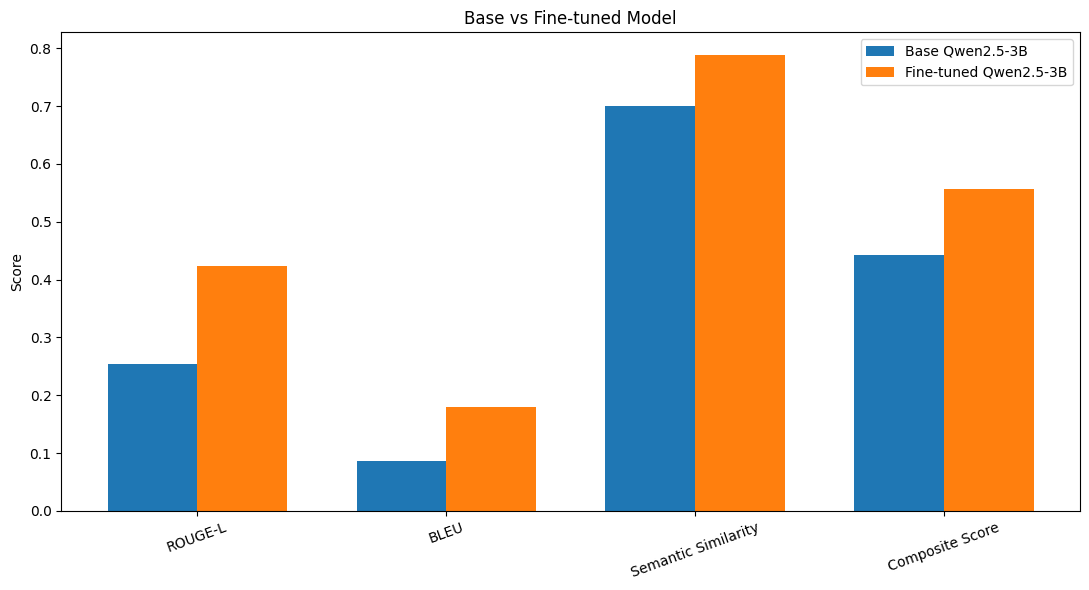

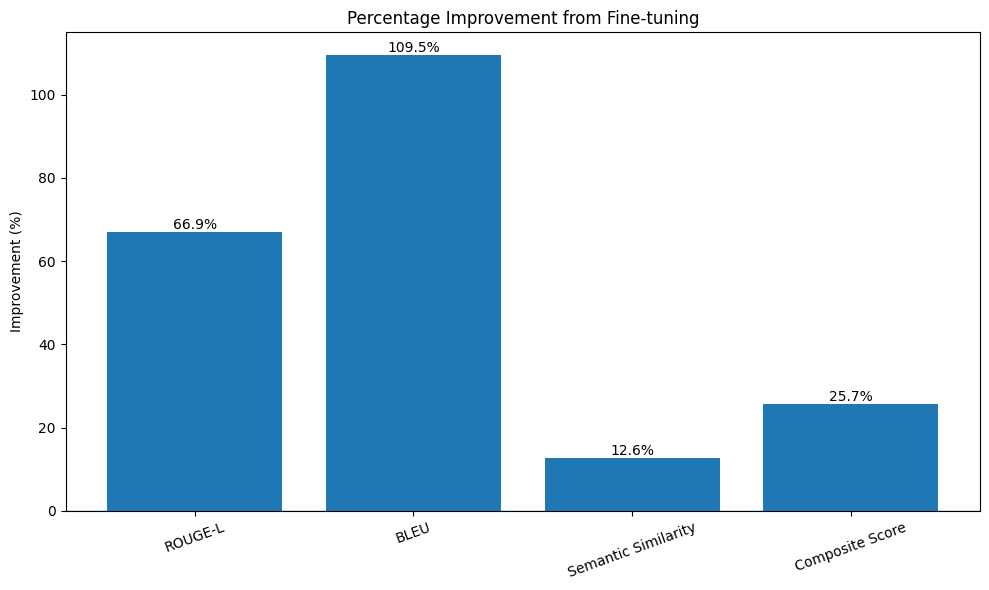

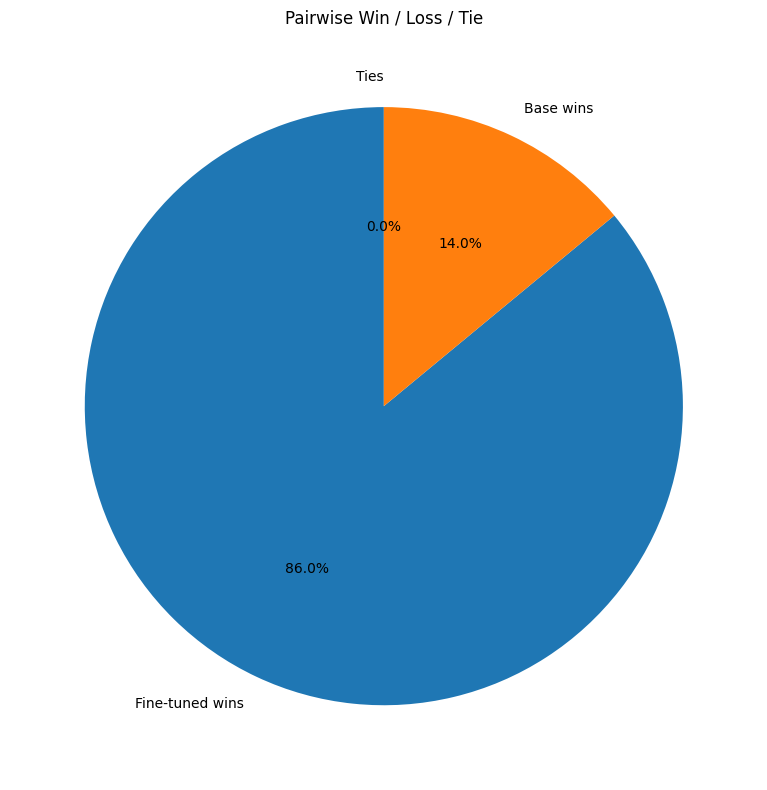

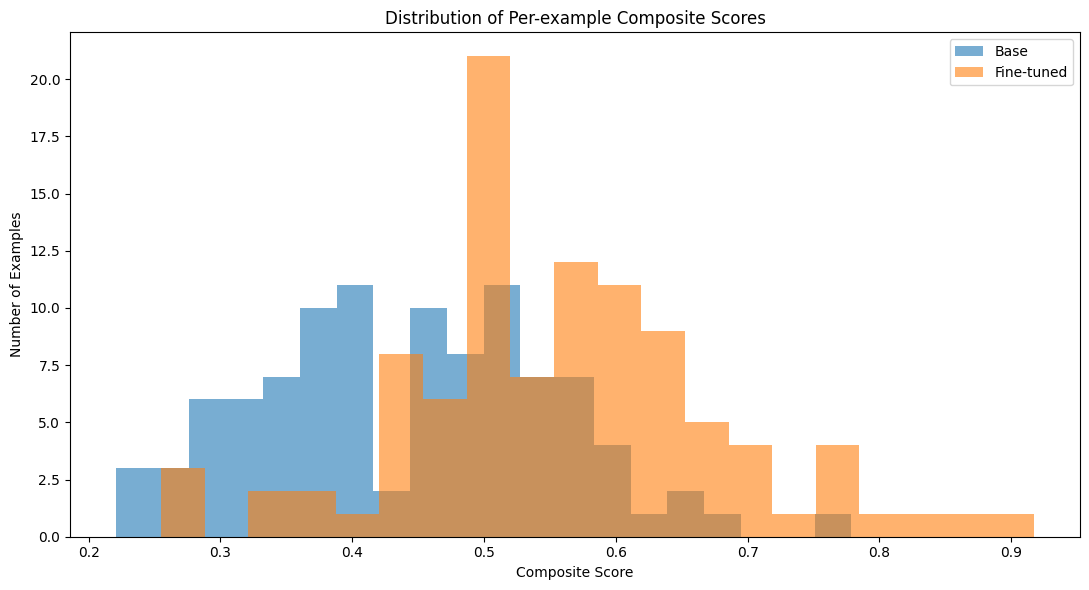

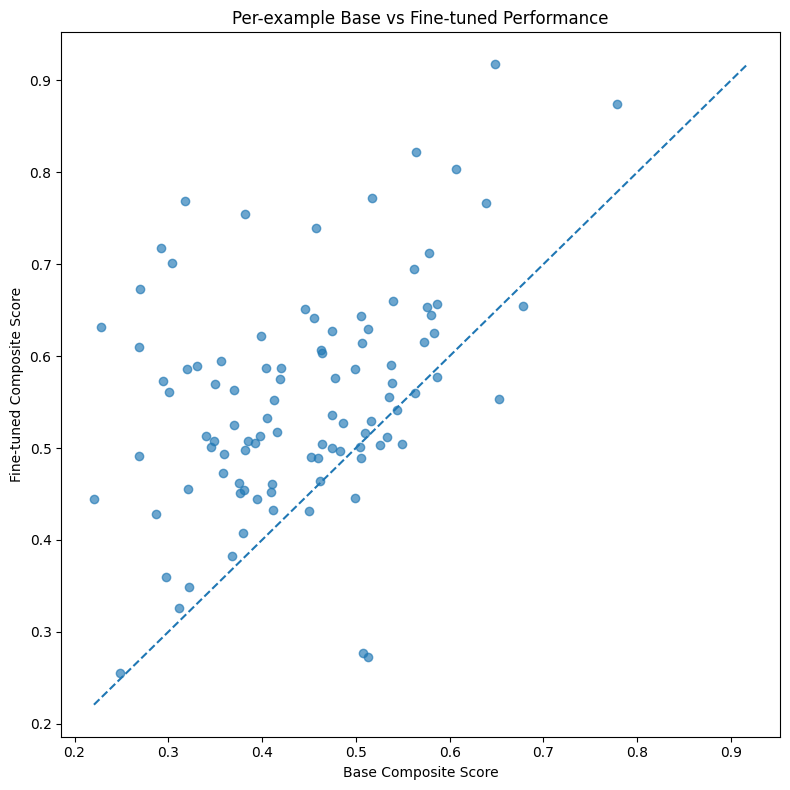

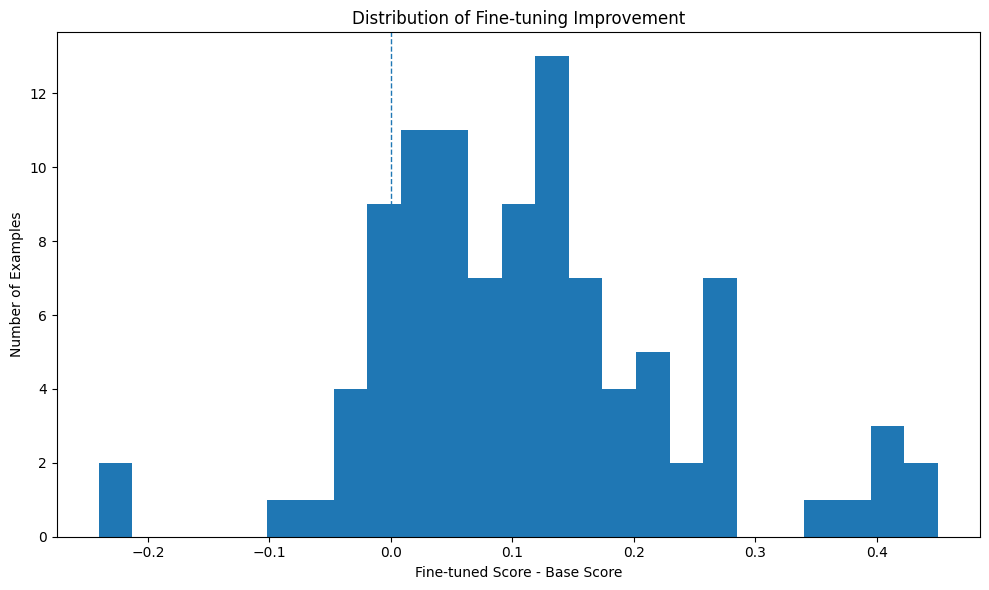

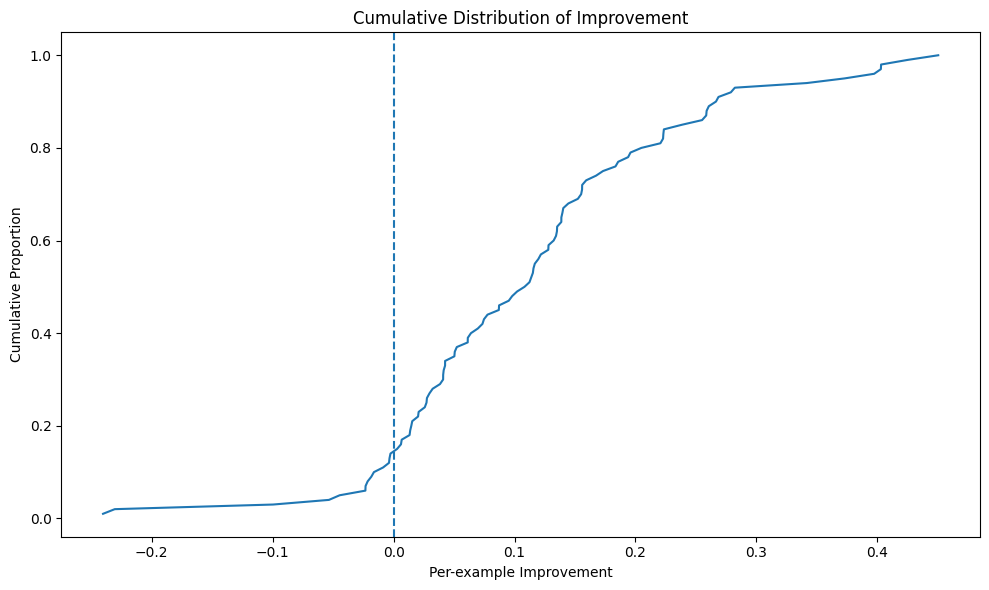

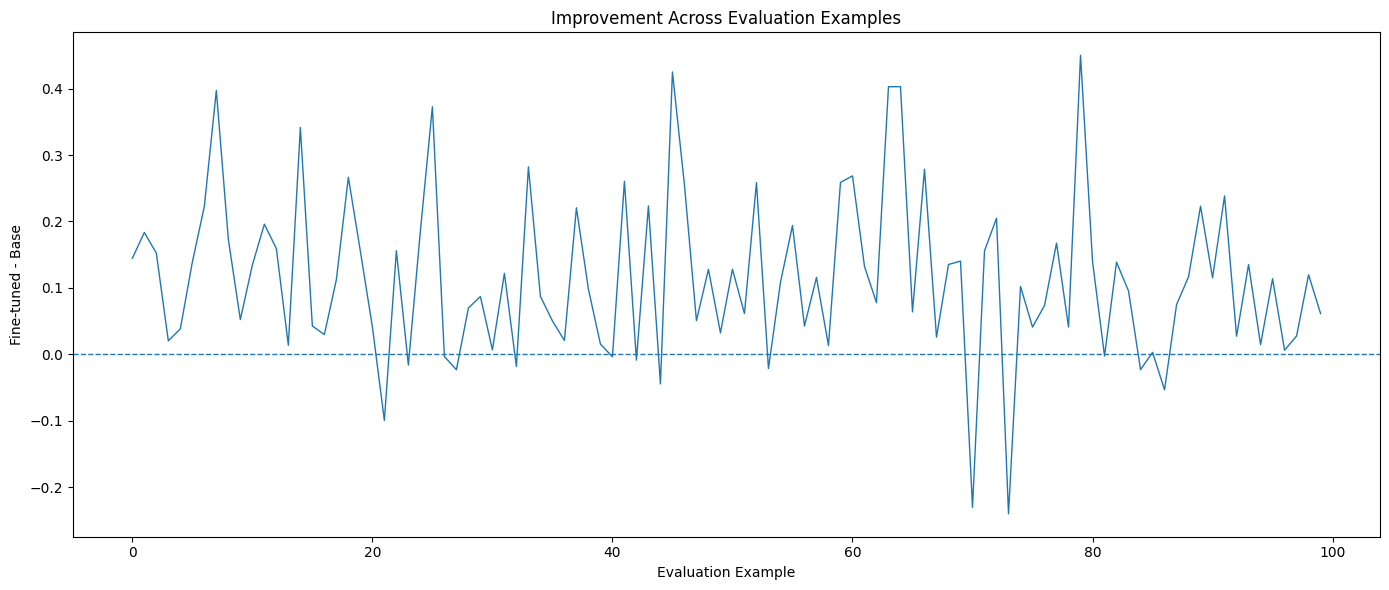

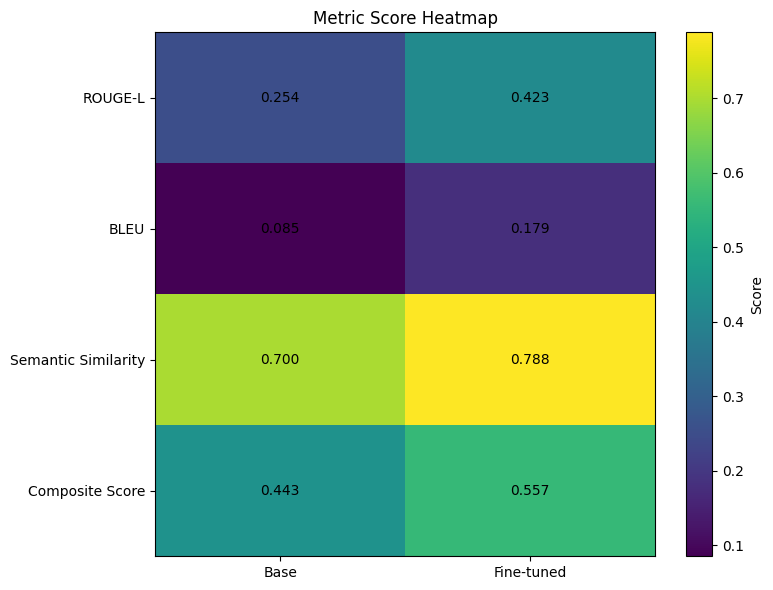

/tmp/ipykernel_58/888145274.py:621: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


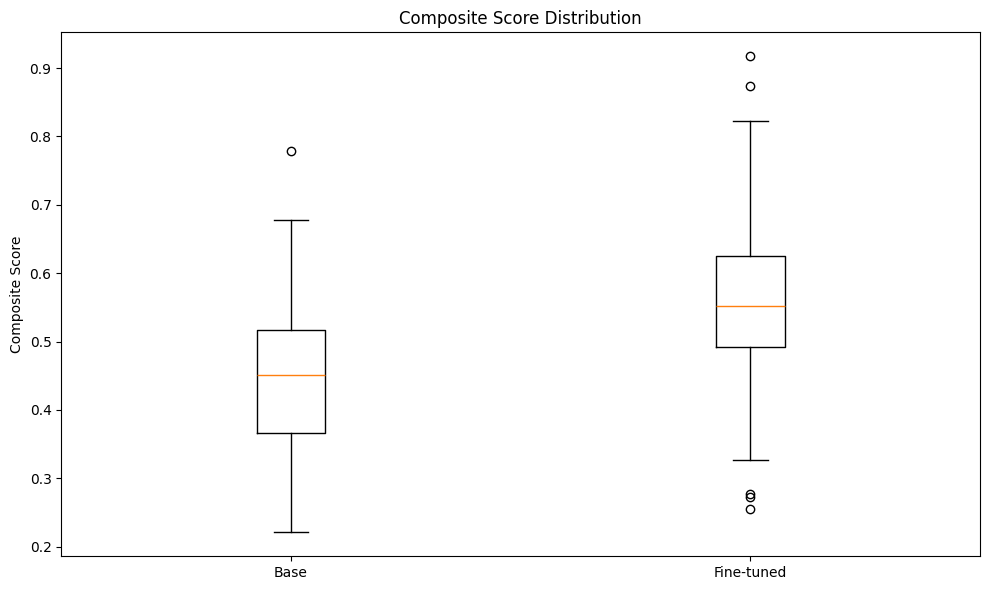

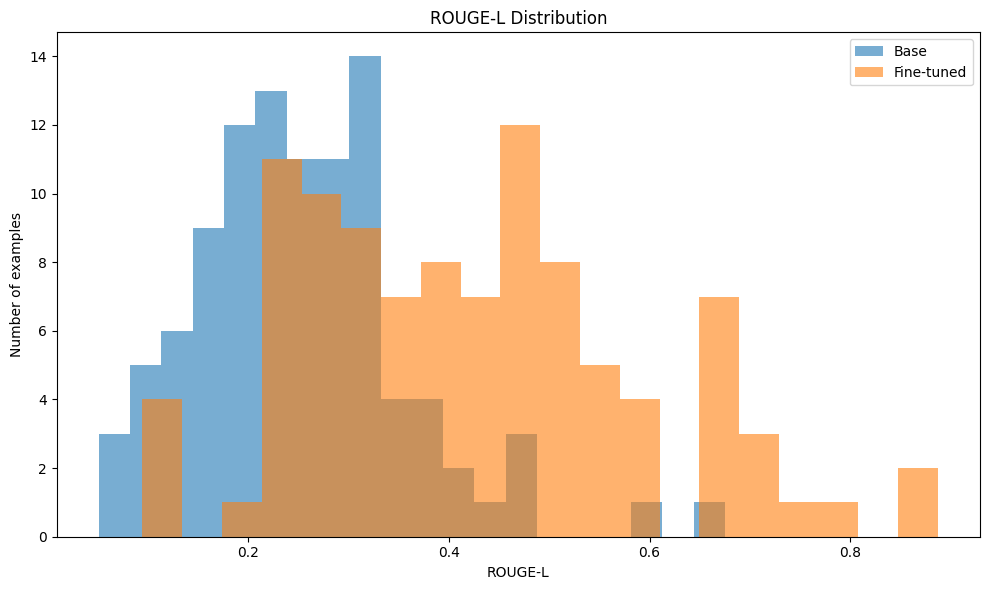

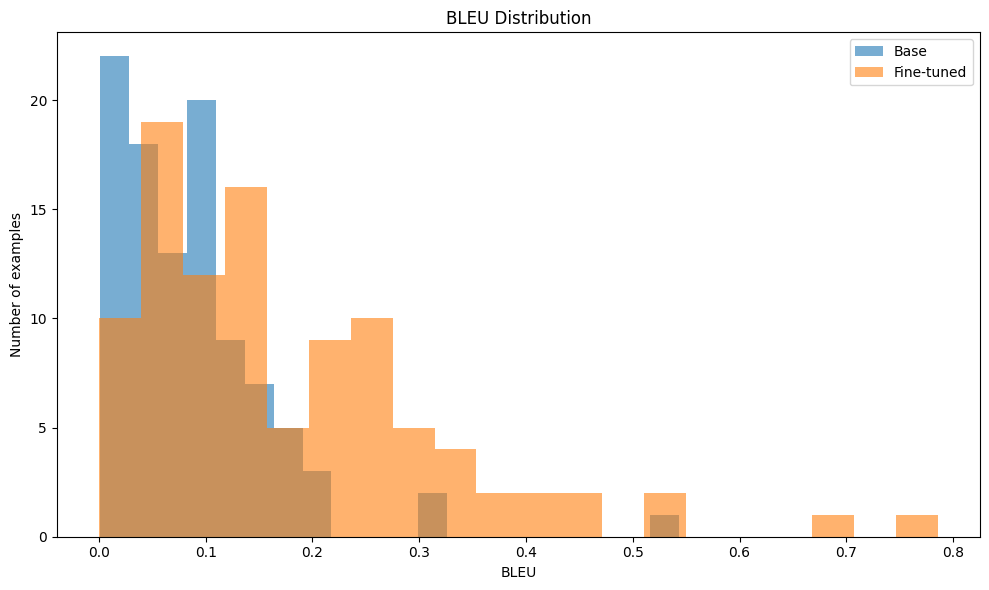

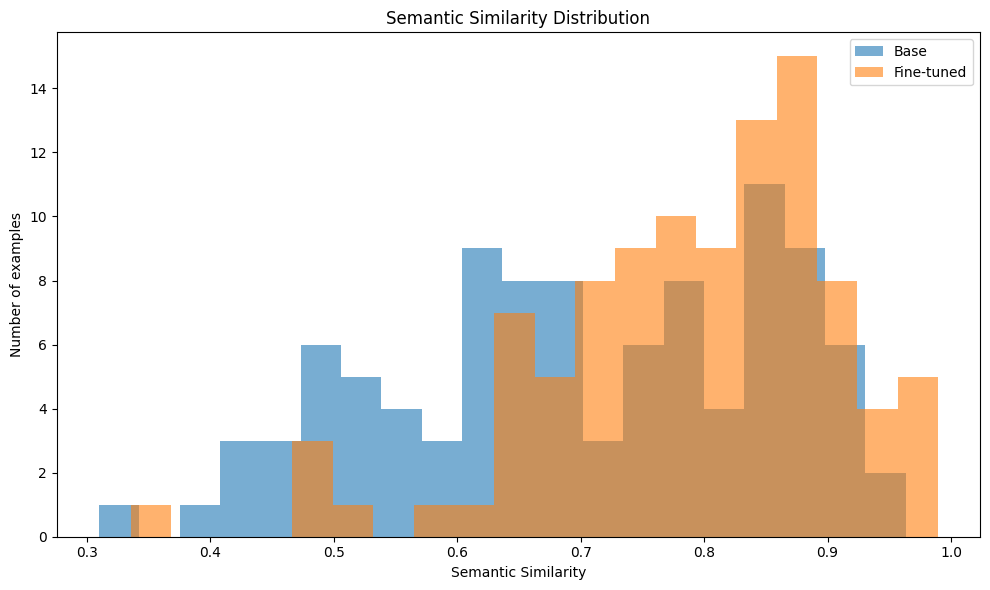

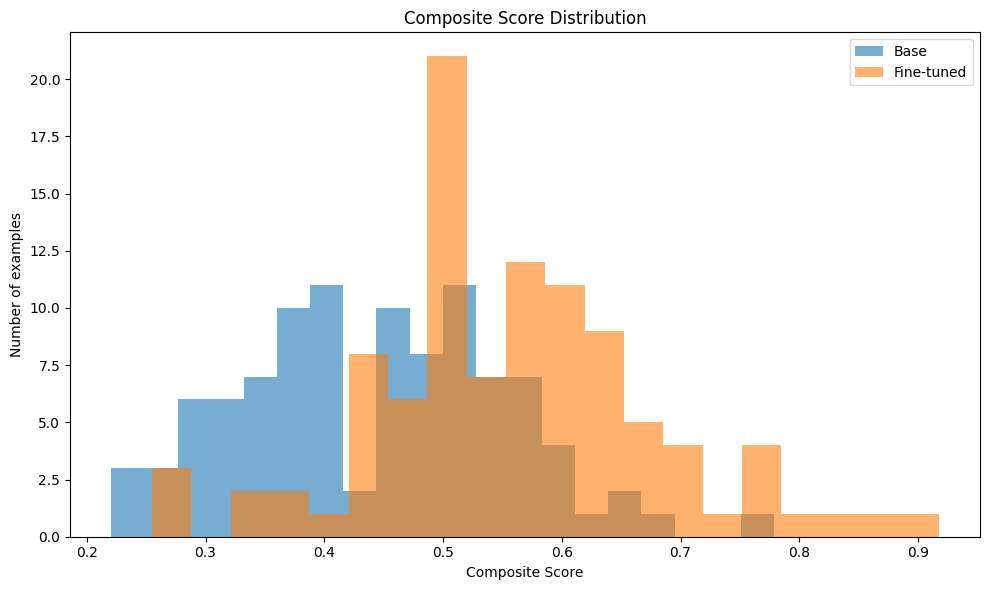


EVALUATION REPORT COMPLETE


,Metric,Base,Fine-tuned,Absolute Gain,Percentage Gain
0,ROUGE-L,0.2535,0.4231,0.1696,+66.89%
1,BLEU,0.0855,0.1791,0.0936,+109.49%
2,Semantic Similarity,0.7001,0.7883,0.0882,+12.60%
3,Composite Score,0.4432,0.5569,0.1137,+25.65%



Win/Loss:
Fine-tuned wins: 86
Base wins: 14
Ties: 0

Fine-tuned win rate: 86.00%

Charts generated: 14

Complete ZIP:
/kaggle/working/qwen25_3b_evaluation_complete.zip

Click below to download EVERYTHING:


/kaggle/working/qwen25_3b_evaluation_complete.zip


Individual report:


/kaggle/working/evaluation_results/report/evaluation_report.md

In [2]:
# ============================================================
# COMPLETE EVALUATION REPORT + CHARTS + ZIP DOWNLOAD
# ============================================================

import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, FileLink


# ============================================================
# 1. PATHS
# ============================================================

RESULTS_DIR = "/kaggle/working/evaluation_results"

CHARTS_DIR = os.path.join(
    RESULTS_DIR,
    "charts"
)

REPORT_DIR = os.path.join(
    RESULTS_DIR,
    "report"
)

os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)


# ============================================================
# 2. LOAD RESULTS
# ============================================================

base_path = os.path.join(
    RESULTS_DIR,
    "base_results.csv"
)

ft_path = os.path.join(
    RESULTS_DIR,
    "finetuned_results.csv"
)

comparison_path = os.path.join(
    RESULTS_DIR,
    "model_comparison.csv"
)

examples_path = os.path.join(
    RESULTS_DIR,
    "example_comparison.csv"
)

summary_path = os.path.join(
    RESULTS_DIR,
    "evaluation_summary.json"
)


base = pd.read_csv(base_path)
ft = pd.read_csv(ft_path)
comparison = pd.read_csv(comparison_path)
examples = pd.read_csv(examples_path)

with open(summary_path, "r") as f:
    summary = json.load(f)


print("Loaded:")
print("Base results:", len(base))
print("Fine-tuned results:", len(ft))
print("Pairwise results:", len(examples))


# ============================================================
# 3. BASIC SUMMARY
# ============================================================

metrics = [
    "rouge_l",
    "bleu",
    "semantic_similarity",
    "composite_score"
]

metric_names = {
    "rouge_l": "ROUGE-L",
    "bleu": "BLEU",
    "semantic_similarity": "Semantic Similarity",
    "composite_score": "Composite Score"
}


# ============================================================
# 4. CHART 1 — GROUPED BAR CHART
# ============================================================

plt.figure(figsize=(11, 6))

x = np.arange(len(metrics))
width = 0.36

base_values = [
    base[m].mean()
    for m in metrics
]

ft_values = [
    ft[m].mean()
    for m in metrics
]

plt.bar(
    x - width / 2,
    base_values,
    width,
    label="Base Qwen2.5-3B"
)

plt.bar(
    x + width / 2,
    ft_values,
    width,
    label="Fine-tuned Qwen2.5-3B"
)

plt.xticks(
    x,
    [metric_names[m] for m in metrics],
    rotation=20
)

plt.ylabel("Score")
plt.title("Base vs Fine-tuned Model")

plt.legend()

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "01_overall_comparison.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. CHART 2 — PERCENT IMPROVEMENT
# ============================================================

improvements = []

for m in metrics:

    b = base[m].mean()
    f = ft[m].mean()

    improvement = (
        (f - b) / abs(b)
    ) * 100

    improvements.append(improvement)


plt.figure(figsize=(10, 6))

bars = plt.bar(
    [metric_names[m] for m in metrics],
    improvements
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Improvement (%)")
plt.title("Percentage Improvement from Fine-tuning")

plt.xticks(
    rotation=20
)

for bar, value in zip(
    bars,
    improvements
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "02_percentage_improvement.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. CHART 3 — WIN / LOSS / TIE
# ============================================================

wins = (
    examples["result"]
    == "fine_tuned_win"
).sum()

losses = (
    examples["result"]
    == "base_win"
).sum()

ties = (
    examples["result"]
    == "tie"
).sum()

labels = [
    "Fine-tuned wins",
    "Base wins",
    "Ties"
]

values = [
    wins,
    losses,
    ties
]

plt.figure(figsize=(8, 8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Pairwise Win / Loss / Tie"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "03_win_loss_tie.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. CHART 4 — PER-EXAMPLE SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 6))

plt.hist(
    examples["base_score"],
    bins=20,
    alpha=0.6,
    label="Base"
)

plt.hist(
    examples["finetuned_score"],
    bins=20,
    alpha=0.6,
    label="Fine-tuned"
)

plt.xlabel("Composite Score")
plt.ylabel("Number of Examples")

plt.title(
    "Distribution of Per-example Composite Scores"
)

plt.legend()

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "04_score_distribution.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. CHART 5 — BASE VS FINE-TUNED SCATTER
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    examples["base_score"],
    examples["finetuned_score"],
    alpha=0.65
)

minimum = min(
    examples["base_score"].min(),
    examples["finetuned_score"].min()
)

maximum = max(
    examples["base_score"].max(),
    examples["finetuned_score"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Base Composite Score"
)

plt.ylabel(
    "Fine-tuned Composite Score"
)

plt.title(
    "Per-example Base vs Fine-tuned Performance"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "05_base_vs_finetuned_scatter.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. CHART 6 — DISTRIBUTION OF IMPROVEMENT
# ============================================================

plt.figure(figsize=(10, 6))

differences = (
    examples["difference"]
)

plt.hist(
    differences,
    bins=25
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Fine-tuned Score - Base Score"
)

plt.ylabel(
    "Number of Examples"
)

plt.title(
    "Distribution of Fine-tuning Improvement"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "06_improvement_distribution.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. CHART 7 — CUMULATIVE IMPROVEMENT
# ============================================================

sorted_differences = np.sort(
    differences
)

cumulative = np.arange(
    1,
    len(sorted_differences) + 1
) / len(sorted_differences)


plt.figure(figsize=(10, 6))

plt.plot(
    sorted_differences,
    cumulative
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Per-example Improvement"
)

plt.ylabel(
    "Cumulative Proportion"
)

plt.title(
    "Cumulative Distribution of Improvement"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "07_cumulative_improvement.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. CHART 8 — PER-EXAMPLE IMPROVEMENT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    examples["index"],
    examples["difference"],
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Evaluation Example"
)

plt.ylabel(
    "Fine-tuned - Base"
)

plt.title(
    "Improvement Across Evaluation Examples"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "08_per_example_improvement.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. CHART 9 — METRIC IMPROVEMENT HEATMAP
# ============================================================

heatmap_data = pd.DataFrame(
    {
        "Base": [
            base[m].mean()
            for m in metrics
        ],

        "Fine-tuned": [
            ft[m].mean()
            for m in metrics
        ]
    },
    index=[
        metric_names[m]
        for m in metrics
    ]
)

plt.figure(figsize=(8, 6))

plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.xticks(
    range(2),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title(
    "Metric Score Heatmap"
)

plt.colorbar(
    label="Score"
)

for i in range(
    heatmap_data.shape[0]
):

    for j in range(
        heatmap_data.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "09_metric_heatmap.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. CHART 10 — BOXPLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        examples["base_score"],
        examples["finetuned_score"]
    ],
    labels=[
        "Base",
        "Fine-tuned"
    ]
)

plt.ylabel(
    "Composite Score"
)

plt.title(
    "Composite Score Distribution"
)

plt.tight_layout()

path = os.path.join(
    CHARTS_DIR,
    "10_boxplot.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. CHART 11 — EACH METRIC DISTRIBUTION
# ============================================================

for metric in metrics:

    plt.figure(figsize=(10, 6))

    plt.hist(
        base[metric],
        bins=20,
        alpha=0.6,
        label="Base"
    )

    plt.hist(
        ft[metric],
        bins=20,
        alpha=0.6,
        label="Fine-tuned"
    )

    plt.xlabel(
        metric_names[metric]
    )

    plt.ylabel(
        "Number of examples"
    )

    plt.title(
        f"{metric_names[metric]} Distribution"
    )

    plt.legend()

    plt.tight_layout()

    filename = (
        "11_distribution_"
        + metric
        + ".png"
    )

    path = os.path.join(
        CHARTS_DIR,
        filename
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 15. TOP IMPROVEMENTS TABLE
# ============================================================

top_improvements = (
    examples
    .sort_values(
        "difference",
        ascending=False
    )
    .head(20)
)

top_improvements[
    [
        "index",
        "base_score",
        "finetuned_score",
        "difference"
    ]
].to_csv(
    os.path.join(
        REPORT_DIR,
        "top_20_improvements.csv"
    ),
    index=False
)


# ============================================================
# 16. TOP REGRESSIONS TABLE
# ============================================================

top_regressions = (
    examples
    .sort_values(
        "difference",
        ascending=True
    )
    .head(20)
)

top_regressions[
    [
        "index",
        "base_score",
        "finetuned_score",
        "difference"
    ]
].to_csv(
    os.path.join(
        REPORT_DIR,
        "top_20_regressions.csv"
    ),
    index=False
)


# ============================================================
# 17. OVERALL STATISTICS
# ============================================================

summary_table = pd.DataFrame({

    "Metric": [
        metric_names[m]
        for m in metrics
    ],

    "Base": [
        base[m].mean()
        for m in metrics
    ],

    "Fine-tuned": [
        ft[m].mean()
        for m in metrics
    ],

    "Absolute Gain": [
        ft[m].mean() - base[m].mean()
        for m in metrics
    ],

    "Percentage Gain": [
        (
            (ft[m].mean() - base[m].mean())
            / abs(base[m].mean())
        ) * 100
        for m in metrics
    ]
})


summary_table.to_csv(
    os.path.join(
        REPORT_DIR,
        "overall_statistics.csv"
    ),
    index=False
)


# ============================================================
# 18. TEXT REPORT
# ============================================================

composite_base = base[
    "composite_score"
].mean()

composite_ft = ft[
    "composite_score"
].mean()

composite_gain = (
    (composite_ft - composite_base)
    / composite_base
) * 100

win_rate = (
    wins
    / len(examples)
) * 100


report = f"""
# Qwen2.5-3B Data Science Fine-tuning Evaluation

## Dataset

Dataset:
{summary.get("dataset", "ed001/ds-coder-instruct-v1")}

Evaluation examples:
{len(examples)}

## Overall Results

| Metric | Base | Fine-tuned | Improvement |
|---|---:|---:|---:|
"""

for _, row in summary_table.iterrows():

    report += (
        f"| {row['Metric']} | "
        f"{row['Base']:.4f} | "
        f"{row['Fine-tuned']:.4f} | "
        f"{row['Percentage Gain']:+.2f}% |\\n"
    )


report += f"""

## Pairwise Results

Fine-tuned wins: {wins}

Base wins: {losses}

Ties: {ties}

Fine-tuned win rate: {win_rate:.2f}%

## Composite Score

Base:
{composite_base:.4f}

Fine-tuned:
{composite_ft:.4f}

Relative improvement:
{composite_gain:.2f}%

## Important Caveat

This benchmark evaluates outputs using ROUGE-L, BLEU,
semantic similarity, and a composite score.

These metrics do not establish that generated Data Science
code is executable or correct.

The evaluation examples are derived from the same dataset
split methodology used during training rather than a
completely independent external benchmark.

Therefore these results demonstrate a strong fine-tuning
signal, but should not be treated as a definitive
production-quality benchmark.

## Recommended Next Step

Evaluate both models on a genuinely unseen Data Science
test set and, where code is generated, execute the code
against test cases whenever possible.
"""


report_path = os.path.join(
    REPORT_DIR,
    "evaluation_report.md"
)

with open(
    report_path,
    "w"
) as f:

    f.write(report)


# ============================================================
# 19. CREATE A HUMAN-READABLE RESULTS CSV
# ============================================================

all_results = examples.copy()

all_results["winner"] = all_results[
    "result"
].map({

    "fine_tuned_win":
        "Fine-tuned",

    "base_win":
        "Base",

    "tie":
        "Tie"
})

all_results.to_csv(
    os.path.join(
        REPORT_DIR,
        "complete_pairwise_results.csv"
    ),
    index=False
)


# ============================================================
# 20. ZIP EVERYTHING
# ============================================================

zip_path = (
    "/kaggle/working/"
    "qwen25_3b_evaluation_complete.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(
        RESULTS_DIR
    ):

        for file in files:

            full_path = os.path.join(
                root,
                file
            )

            # Don't recursively include the zip
            if full_path == zip_path:
                continue

            relative_path = os.path.relpath(
                full_path,
                RESULTS_DIR
            )

            z.write(
                full_path,
                os.path.join(
                    "evaluation_results",
                    relative_path
                )
            )


# ============================================================
# 21. DISPLAY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EVALUATION REPORT COMPLETE")
print("=" * 70)

display(
    summary_table.style.format({
        "Base": "{:.4f}",
        "Fine-tuned": "{:.4f}",
        "Absolute Gain": "{:.4f}",
        "Percentage Gain": "{:+.2f}%"
    })
)

print("\nWin/Loss:")
print("Fine-tuned wins:", wins)
print("Base wins:", losses)
print("Ties:", ties)

print(
    f"\nFine-tuned win rate: {win_rate:.2f}%"
)

print("\nCharts generated:", len(
    os.listdir(CHARTS_DIR)
))

print("\nComplete ZIP:")
print(zip_path)

print("\nClick below to download EVERYTHING:")
display(
    FileLink(
        zip_path,
        result_html_prefix="Download: "
    )
)

print("\nIndividual report:")
display(
    FileLink(
        report_path,
        result_html_prefix="Download report: "
    )
)

In [4]:
import os
import zipfile

RESULTS_DIR = "/kaggle/working/evaluation_results"
ZIP_PATH = "/kaggle/working/qwen25_3b_evaluation_complete.zip"

# Recreate ZIP
with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(RESULTS_DIR):
        for file in files:
            full_path = os.path.join(root, file)

            # Path inside ZIP
            arcname = os.path.relpath(
                full_path,
                RESULTS_DIR
            )

            z.write(
                full_path,
                arcname
            )

print("ZIP ready:")
print(ZIP_PATH)
print(
    "Size:",
    round(os.path.getsize(ZIP_PATH) / (1024**2), 2),
    "MB"
)

ZIP ready:
/kaggle/working/qwen25_3b_evaluation_complete.zip
Size: 1.3 MB
